# Recommender Systems: Personalized Movie Recommendations

## Business Framing
The company aims to improve user engagement, session depth, and retention by serving relevant movie recommendations for each user.
This notebook delivers a production-oriented recommendation analysis using explicit ratings, demographics, and movie metadata.

## Problem Definition
Build and evaluate a personalized movie recommender system that can:
- predict user rating preferences reliably,
- generate high-relevance recommendations,
- remain scalable under sparse user-item interactions.

## Success Criteria
- Lower prediction error (RMSE, MAPE) on unseen interactions.
- Better top-N recommendation relevance.
- Clear trade-offs across collaborative filtering techniques.

## Confidentiality
No client/company names are exposed in this analysis.

## Analytical Scope and Delivery Plan

This case study covers:
1. Data ingestion and quality diagnostics
2. Exploratory data analysis (univariate, bivariate, multivariate)
3. Feature engineering and sparse-matrix preparation
4. Baseline recommenders and tuned collaborative filtering models
5. Matrix factorization with validation-driven tuning
6. Questionnaire answers and executive-level interpretation
7. Risks, assumptions, and monitoring plan

Primary modeling approaches:
- Item-based collaborative filtering (Pearson correlation)
- User-based collaborative filtering (Cosine similarity)
- Matrix factorization (Truncated SVD)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MultiLabelBinarizer

from scipy.sparse import csr_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [2]:
data_dir = Path("../data")

ratings_cols = ["UserID", "MovieID", "Rating", "Timestamp"]
users_cols = ["UserID", "Gender", "Age", "Occupation", "ZipCode"]
movies_cols = ["MovieID", "Title", "Genres"]

ratings = pd.read_csv(data_dir / "zee-ratings.dat", sep="::", engine="python", names=ratings_cols, encoding="latin-1")
users = pd.read_csv(data_dir / "zee-users.dat", sep="::", engine="python", names=users_cols, encoding="latin-1")
movies = pd.read_csv(data_dir / "zee-movies.dat", sep="::", engine="python", names=movies_cols, encoding="latin-1")

# Remove accidental header rows embedded as first records and enforce schema types
ratings = ratings[ratings["UserID"] != "UserID"].copy()
users = users[users["UserID"] != "UserID"].copy()
movies = movies[movies["MovieID"] != "Movie ID"].copy()

ratings[["UserID", "MovieID", "Rating", "Timestamp"]] = ratings[["UserID", "MovieID", "Rating", "Timestamp"]].apply(pd.to_numeric, errors="coerce")
users[["UserID", "Age", "Occupation"]] = users[["UserID", "Age", "Occupation"]].apply(pd.to_numeric, errors="coerce")
movies["MovieID"] = pd.to_numeric(movies["MovieID"], errors="coerce")

ratings = ratings.dropna(subset=["UserID", "MovieID", "Rating", "Timestamp"]).astype({"UserID": "int64", "MovieID": "int64", "Rating": "float64", "Timestamp": "int64"})
users = users.dropna(subset=["UserID", "Age", "Occupation"]).astype({"UserID": "int64", "Age": "int64", "Occupation": "int64"})
movies = movies.dropna(subset=["MovieID", "Title", "Genres"]).astype({"MovieID": "int64"})

print("Shapes:")
print("ratings:", ratings.shape)
print("users  :", users.shape)
print("movies :", movies.shape)

display(ratings.head(3))
display(users.head(3))
display(movies.head(3))

Shapes:
ratings: (1000209, 4)
users  : (6040, 5)
movies : (3883, 3)


,UserID,MovieID,Rating,Timestamp
1,1,1193,5.0,978300760
2,1,661,3.0,978302109
3,1,914,3.0,978301968


,UserID,Gender,Age,Occupation,ZipCode
1,1,F,1,10,48067
2,2,M,56,16,70072
3,3,M,25,15,55117


,MovieID,Title,Genres
1,1,Toy Story (1995),Animation|Children's|Comedy
2,2,Jumanji (1995),Adventure|Children's|Fantasy
3,3,Grumpier Old Men (1995),Comedy|Romance


In [3]:
def quick_data_quality(df, name):
    print(f"\n{name} schema")
    display(df.dtypes.to_frame("dtype"))
    miss = df.isna().sum().to_frame("missing_count")
    miss["missing_pct"] = (miss["missing_count"] / len(df) * 100).round(3)
    print(f"{name} missing values")
    display(miss)
    print(f"{name} duplicates: {df.duplicated().sum()}")

quick_data_quality(ratings, "ratings")
quick_data_quality(users, "users")
quick_data_quality(movies, "movies")

print("\nRatings summary:")
display(ratings["Rating"].describe())

print("Unique users in ratings:", ratings["UserID"].nunique())
print("Unique movies in ratings:", ratings["MovieID"].nunique())


ratings schema


,dtype
UserID,int64
MovieID,int64
Rating,float64
Timestamp,int64


ratings missing values


,missing_count,missing_pct
UserID,0,0.0
MovieID,0,0.0
Rating,0,0.0
Timestamp,0,0.0


ratings duplicates: 0

users schema


...

movies missing values


,missing_count,missing_pct
MovieID,0,0.0
Title,0,0.0
Genres,0,0.0


movies duplicates: 0

Ratings summary:


count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64

Unique users in ratings: 6040
Unique movies in ratings: 3706


Merged shape: (1000209, 14)


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,ZipCode,Title,Genres,ReleaseYear,Decade,RatingDate,RatingYear
0,1,1193,5.0,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,1975.0,1970,2000-12-31 22:12:40,2000
1,1,661,3.0,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,1996.0,1990,2000-12-31 22:35:09,2000
2,1,914,3.0,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance,1964.0,1960,2000-12-31 22:32:48,2000


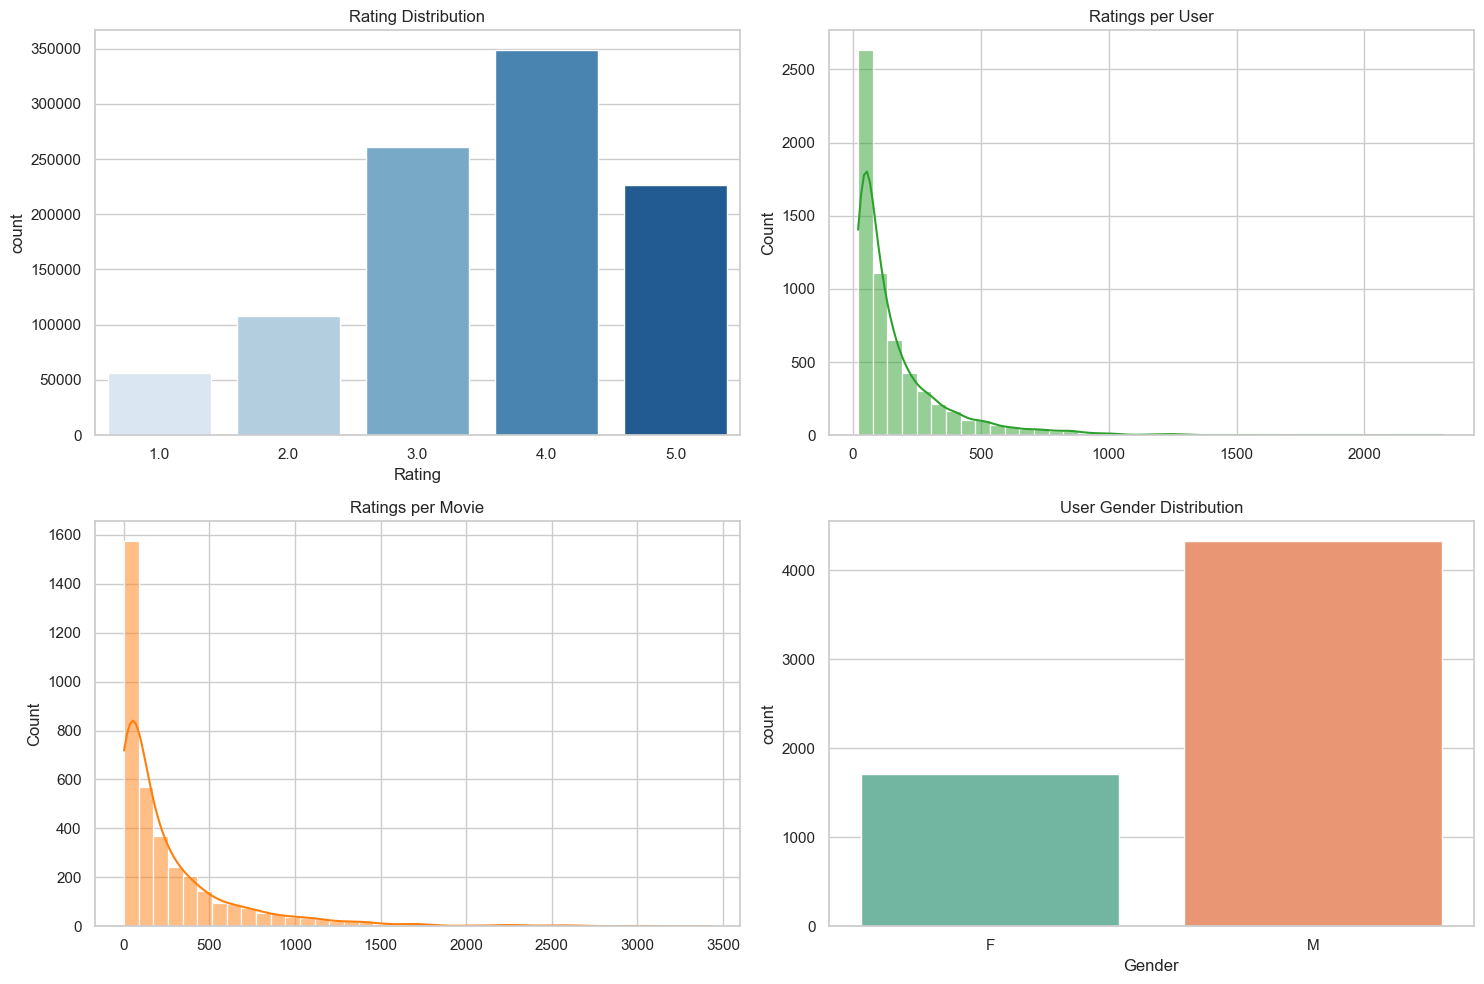

Skewness diagnostics
Ratings per user skewness: 2.745
Ratings per movie skewness: 2.815
Insight: interaction counts are highly right-skewed, confirming sparsity and popularity concentration.


In [4]:
# Merge tables for richer EDA
movies["ReleaseYear"] = movies["Title"].str.extract(r"\((\d{4})\)").astype(float)
movies["Decade"] = (movies["ReleaseYear"] // 10 * 10).astype("Int64")

ratings_enriched = ratings.merge(users, on="UserID", how="left").merge(movies, on="MovieID", how="left")
ratings_enriched["RatingDate"] = pd.to_datetime(ratings_enriched["Timestamp"], unit="s", errors="coerce")
ratings_enriched["RatingYear"] = ratings_enriched["RatingDate"].dt.year

print("Merged shape:", ratings_enriched.shape)
display(ratings_enriched.head(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=ratings, x="Rating", ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Rating Distribution")

user_activity = ratings.groupby("UserID").size()
sns.histplot(user_activity, bins=40, kde=True, ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Ratings per User")

movie_activity = ratings.groupby("MovieID").size()
sns.histplot(movie_activity, bins=40, kde=True, ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Ratings per Movie")

sns.countplot(data=users, x="Gender", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("User Gender Distribution")

plt.tight_layout()
plt.show()

print("Skewness diagnostics")
print("Ratings per user skewness:", round(user_activity.skew(), 3))
print("Ratings per movie skewness:", round(movie_activity.skew(), 3))
print("Insight: interaction counts are highly right-skewed, confirming sparsity and popularity concentration.")

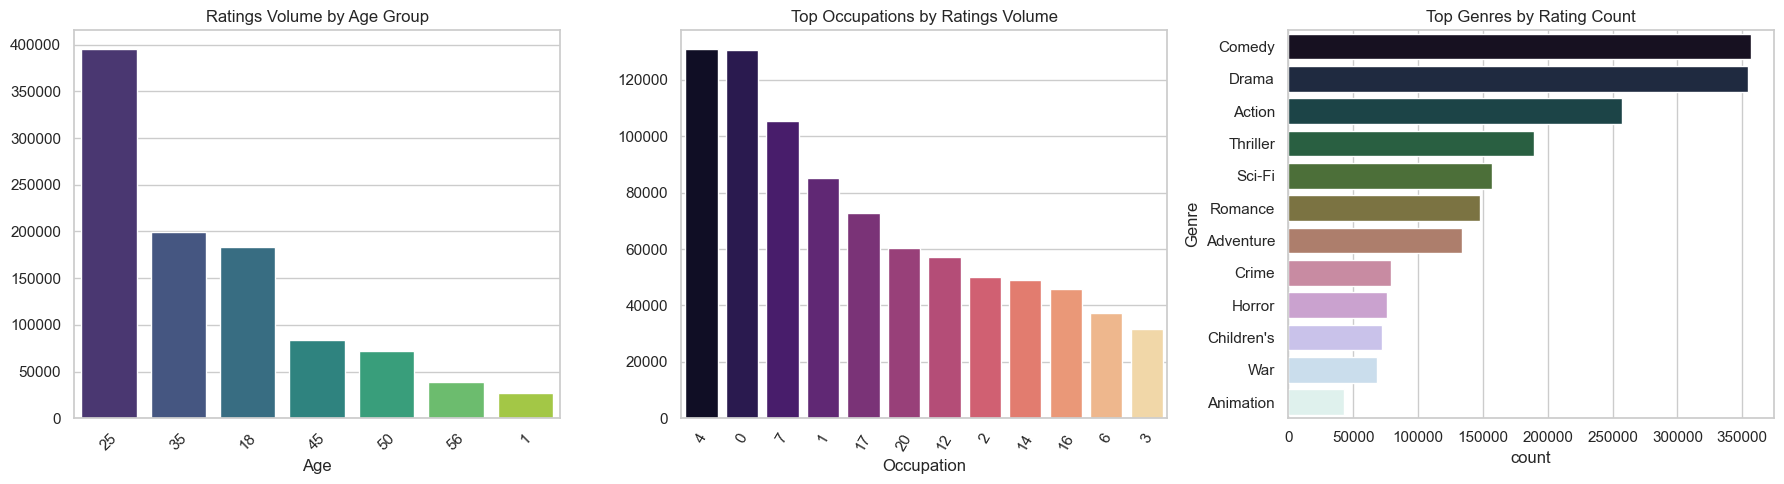

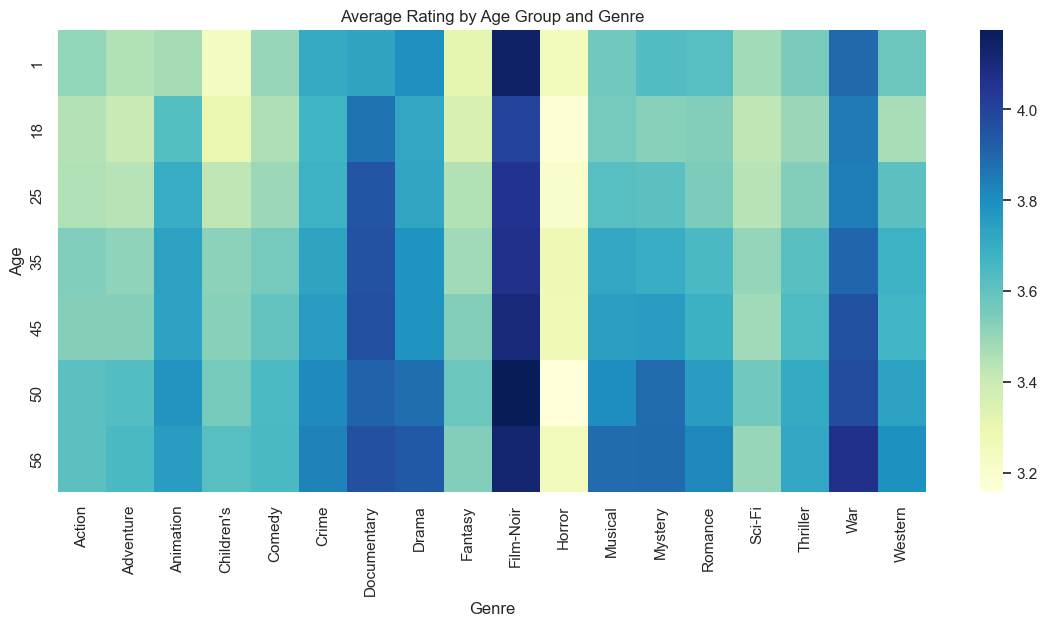

Initial EDA insights captured.


In [5]:
# Bivariate and multivariate EDA
age_activity = ratings_enriched.groupby("Age")["MovieID"].count().sort_values(ascending=False)
occupation_activity = ratings_enriched.groupby("Occupation")["MovieID"].count().sort_values(ascending=False)

genre_exploded = ratings_enriched.assign(Genre=ratings_enriched["Genres"].str.split("|", regex=False)).explode("Genre")
genre_rating = genre_exploded.groupby("Genre")["Rating"].agg(["count", "mean"]).sort_values("count", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=age_activity.index.astype(str), y=age_activity.values, ax=axes[0], palette="viridis")
axes[0].set_title("Ratings Volume by Age Group")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=occupation_activity.head(12).index.astype(str), y=occupation_activity.head(12).values, ax=axes[1], palette="magma")
axes[1].set_title("Top Occupations by Ratings Volume")
axes[1].tick_params(axis="x", rotation=60)

sns.barplot(y=genre_rating.head(12).index, x=genre_rating.head(12)["count"], ax=axes[2], palette="cubehelix")
axes[2].set_title("Top Genres by Rating Count")

plt.tight_layout()
plt.show()

genre_pivot = genre_exploded.pivot_table(index="Age", columns="Genre", values="Rating", aggfunc="mean")
plt.figure(figsize=(14, 6))
sns.heatmap(genre_pivot, cmap="YlGnBu", annot=False)
plt.title("Average Rating by Age Group and Genre")
plt.show()

print("Initial EDA insights captured.")

In [6]:
## Preprocessing and feature engineering
ratings_model = ratings.copy()
ratings_model = ratings_model.sort_values(["UserID", "Timestamp"]).reset_index(drop=True)

# Core aggregate features
user_stats = ratings_model.groupby("UserID")["Rating"].agg(user_mean="mean", user_count="count")
movie_stats = ratings_model.groupby("MovieID")["Rating"].agg(movie_mean="mean", movie_count="count")

ratings_model = ratings_model.join(user_stats, on="UserID")
ratings_model = ratings_model.join(movie_stats, on="MovieID")

print("Feature-engineered ratings sample:")
display(ratings_model.head(3))

def temporal_user_split(df, min_interactions=5):
    train_parts, val_parts, test_parts = [], [], []
    for _, grp in df.groupby("UserID", sort=False):
        grp = grp.sort_values("Timestamp")
        n = len(grp)
        if n >= min_interactions:
            test_parts.append(grp.iloc[[-1]])
            val_parts.append(grp.iloc[[-2]])
            train_parts.append(grp.iloc[:-2])
        elif n >= 3:
            test_parts.append(grp.iloc[[-1]])
            val_parts.append(grp.iloc[[-2]])
            train_parts.append(grp.iloc[:-2])
        else:
            train_parts.append(grp)

    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else pd.DataFrame(columns=df.columns)
    val_df = pd.concat(val_parts, ignore_index=True) if val_parts else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=df.columns)
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_user_split(ratings_model)
print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Users in train/val/test:", train_df['UserID'].nunique(), val_df['UserID'].nunique(), test_df['UserID'].nunique())

global_mean = train_df["Rating"].mean()
print("Global mean rating in train:", round(global_mean, 4))

Feature-engineered ratings sample:


,UserID,MovieID,Rating,Timestamp,user_mean,user_count,movie_mean,movie_count
0,1,3186,4.0,978300019,4.188679,53,3.477958,431
1,1,1270,5.0,978300055,4.188679,53,3.990321,2583
2,1,1721,4.0,978300055,4.188679,53,3.583441,1546


Split sizes: 988129 6040 6040
Users in train/val/test: 6040 6040 6040
Global mean rating in train: 3.5815


In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    non_zero = y_true != 0
    if non_zero.sum() == 0:
        return np.nan
    return float(mean_absolute_percentage_error(y_true[non_zero], y_pred[non_zero]))

def clip_rating(x, low=1.0, high=5.0):
    return np.clip(x, low, high)

def evaluate_predictions(df_true, pred_col="pred"):
    return {
        "RMSE": rmse(df_true["Rating"], df_true[pred_col]),
        "MAPE": mape(df_true["Rating"], df_true[pred_col])
    }

# Baseline 1: global mean
val_pred_global = val_df.copy()
val_pred_global["pred"] = global_mean
test_pred_global = test_df.copy()
test_pred_global["pred"] = global_mean

global_val_metrics = evaluate_predictions(val_pred_global)
global_test_metrics = evaluate_predictions(test_pred_global)
print("Global baseline (val):", global_val_metrics)
print("Global baseline (test):", global_test_metrics)

# Baseline 2: regularized user-item bias model
def fit_bias_model(train, reg=10.0, n_iter=8):
    mu = train["Rating"].mean()
    bu = pd.Series(0.0, index=train["UserID"].unique())
    bi = pd.Series(0.0, index=train["MovieID"].unique())

    for _ in range(n_iter):
        # Update user biases
        tmp = train.join(bi.rename("bi"), on="MovieID")
        num_u = tmp.groupby("UserID").apply(lambda g: (g["Rating"] - mu - g["bi"]).sum())
        cnt_u = tmp.groupby("UserID").size()
        bu = (num_u / (cnt_u + reg)).reindex(bu.index).fillna(0.0)

        # Update item biases
        tmp = train.join(bu.rename("bu"), on="UserID")
        num_i = tmp.groupby("MovieID").apply(lambda g: (g["Rating"] - mu - g["bu"]).sum())
        cnt_i = tmp.groupby("MovieID").size()
        bi = (num_i / (cnt_i + reg)).reindex(bi.index).fillna(0.0)

    return mu, bu, bi

def predict_bias(df_eval, mu, bu, bi):
    pred = (
        mu
        + df_eval["UserID"].map(bu).fillna(0.0)
        + df_eval["MovieID"].map(bi).fillna(0.0)
    )
    return clip_rating(pred.values)

reg_grid = [5.0, 10.0, 20.0, 40.0]
bias_scores = []
best_bias = None
best_val_rmse = np.inf

for reg in reg_grid:
    mu, bu, bi = fit_bias_model(train_df, reg=reg, n_iter=8)
    v = val_df.copy()
    v["pred"] = predict_bias(v, mu, bu, bi)
    score = evaluate_predictions(v)
    bias_scores.append({"reg": reg, **score})
    if score["RMSE"] < best_val_rmse:
        best_val_rmse = score["RMSE"]
        best_bias = (mu, bu, bi, reg)

bias_score_df = pd.DataFrame(bias_scores).sort_values("RMSE")
display(bias_score_df)

mu_b, bu_b, bi_b, best_reg = best_bias
test_bias = test_df.copy()
test_bias["pred"] = predict_bias(test_bias, mu_b, bu_b, bi_b)
bias_test_metrics = evaluate_predictions(test_bias)
print(f"Best bias-model reg: {best_reg}")
print("Bias model (test):", bias_test_metrics)

Global baseline (val): {'RMSE': 1.1584898475322987, 'MAPE': 0.40937426811225724}
Global baseline (test): {'RMSE': 1.1755651985279745, 'MAPE': 0.4136629200068449}


,reg,RMSE,MAPE
0,5.0,0.939383,0.296606
1,10.0,0.940191,0.299171
2,20.0,0.943328,0.303724
3,40.0,0.951043,0.310951


Best bias-model reg: 5.0
Bias model (test): {'RMSE': 0.9652078657563132, 'MAPE': 0.2999148801084146}


In [8]:
# Build index mappings for sparse matrices
user_ids = np.sort(train_df["UserID"].unique())
movie_ids = np.sort(train_df["MovieID"].unique())
u2i = {u: i for i, u in enumerate(user_ids)}
m2i = {m: i for i, m in enumerate(movie_ids)}

train_idx = train_df[train_df["UserID"].isin(u2i) & train_df["MovieID"].isin(m2i)].copy()
rows = train_idx["UserID"].map(u2i).values
cols = train_idx["MovieID"].map(m2i).values
vals = train_idx["Rating"].astype(float).values

R = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), len(movie_ids)))
R_dense = R.toarray()

# Item-based Pearson (ratings centered by user mean)
user_mean_vec = np.where((R_dense != 0).sum(axis=1) > 0, R_dense.sum(axis=1) / np.maximum((R_dense != 0).sum(axis=1), 1), global_mean)
R_centered = R_dense.copy()
for i in range(R_centered.shape[0]):
    mask = R_centered[i] != 0
    R_centered[i, mask] = R_centered[i, mask] - user_mean_vec[i]

item_corr = np.corrcoef(R_centered.T)
item_corr = np.nan_to_num(item_corr, nan=0.0, posinf=0.0, neginf=0.0)

# User-based Cosine similarity
user_cos = cosine_similarity(R)
np.fill_diagonal(user_cos, 0.0)

print("Matrices ready:")
print("R shape:", R.shape, "Item corr:", item_corr.shape, "User cosine:", user_cos.shape)

def predict_item_pearson(user_id, movie_id, k=40):
    if user_id not in u2i or movie_id not in m2i:
        return global_mean
    u = u2i[user_id]
    m = m2i[movie_id]
    user_ratings = R_dense[u]
    rated_idx = np.where(user_ratings > 0)[0]
    if len(rated_idx) == 0:
        return global_mean

    sims = item_corr[m, rated_idx]
    top_idx = np.argsort(np.abs(sims))[::-1][:k]
    sims_top = sims[top_idx]
    ratings_top = user_ratings[rated_idx[top_idx]]

    denom = np.sum(np.abs(sims_top))
    if denom == 0:
        return user_mean_vec[u]
    pred = np.dot(sims_top, ratings_top) / denom
    return float(clip_rating(pred))

def predict_user_cosine(user_id, movie_id, k=40):
    if user_id not in u2i or movie_id not in m2i:
        return global_mean
    u = u2i[user_id]
    m = m2i[movie_id]
    movie_col = R_dense[:, m]
    raters = np.where(movie_col > 0)[0]
    if len(raters) == 0:
        return global_mean

    sims = user_cos[u, raters]
    top_idx = np.argsort(np.abs(sims))[::-1][:k]
    sims_top = sims[top_idx]
    ratings_top = movie_col[raters[top_idx]]

    denom = np.sum(np.abs(sims_top))
    if denom == 0:
        return user_mean_vec[u]
    pred = np.dot(sims_top, ratings_top) / denom
    return float(clip_rating(pred))

def batch_predict(df_eval, predictor, k=40):
    return np.array([predictor(u, m, k=k) for u, m in zip(df_eval["UserID"], df_eval["MovieID"])])

k_grid = [20, 40, 80]
item_scores = []
user_scores = []

for k in k_grid:
    v_item = val_df.copy()
    v_item["pred"] = batch_predict(v_item, predict_item_pearson, k=k)
    item_scores.append({"k": k, **evaluate_predictions(v_item)})

    v_user = val_df.copy()
    v_user["pred"] = batch_predict(v_user, predict_user_cosine, k=k)
    user_scores.append({"k": k, **evaluate_predictions(v_user)})

item_scores_df = pd.DataFrame(item_scores).sort_values("RMSE")
user_scores_df = pd.DataFrame(user_scores).sort_values("RMSE")
display(item_scores_df)
display(user_scores_df)

best_k_item = int(item_scores_df.iloc[0]["k"])
best_k_user = int(user_scores_df.iloc[0]["k"])

test_item = test_df.copy()
test_item["pred"] = batch_predict(test_item, predict_item_pearson, k=best_k_item)
item_test_metrics = evaluate_predictions(test_item)

test_user = test_df.copy()
test_user["pred"] = batch_predict(test_user, predict_user_cosine, k=best_k_user)
user_test_metrics = evaluate_predictions(test_user)

print(f"Best item-based Pearson k: {best_k_item}, test metrics: {item_test_metrics}")
print(f"Best user-based Cosine k: {best_k_user}, test metrics: {user_test_metrics}")

Matrices ready:
R shape: (6040, 3704) Item corr: (3704, 3704) User cosine: (6040, 6040)


,k,RMSE,MAPE
0,20,1.726019,0.392207
1,40,1.855591,0.420459
2,80,1.954279,0.444193


,k,RMSE,MAPE
2,80,0.989241,0.312508
1,40,0.990304,0.311779
0,20,0.997068,0.312476


Best item-based Pearson k: 20, test metrics: {'RMSE': 1.7793672826000773, 'MAPE': 0.4000916203261543}
Best user-based Cosine k: 80, test metrics: {'RMSE': 1.0036411945109756, 'MAPE': 0.31216639197813173}


In [9]:
# Item-based similar movies for 'Liar Liar' (Pearson approach)
title_to_id = movies.drop_duplicates("Title").set_index("Title")["MovieID"].to_dict()
id_to_title = movies.drop_duplicates("MovieID").set_index("MovieID")["Title"].to_dict()

target_title = "Liar Liar (1997)"
if target_title in title_to_id and title_to_id[target_title] in m2i:
    target_mid = title_to_id[target_title]
    t_idx = m2i[target_mid]
    sims = item_corr[t_idx]
    order = np.argsort(sims)[::-1]
    top_similar = []
    for idx in order:
        if idx == t_idx:
            continue
        mid = movie_ids[idx]
        title = id_to_title.get(mid, str(mid))
        top_similar.append((title, float(sims[idx])))
        if len(top_similar) == 3:
            break
    print("Top 3 movies similar to Liar Liar (item-based Pearson):")
    display(pd.DataFrame(top_similar, columns=["SimilarMovie", "PearsonSimilarity"]))
else:
    top_similar = []
    print("Liar Liar (1997) not found in train item index.")

def recommend_for_user(user_id, method="item", top_n=10):
    watched = set(ratings.loc[ratings["UserID"] == user_id, "MovieID"].tolist())
    candidates = [m for m in movie_ids if m not in watched]
    if len(candidates) == 0:
        return pd.DataFrame(columns=["MovieID", "Title", "PredRating"])

    preds = []
    for mid in candidates:
        if method == "item":
            p = predict_item_pearson(user_id, mid, k=best_k_item)
        else:
            p = predict_user_cosine(user_id, mid, k=best_k_user)
        preds.append((mid, p))

    recs = pd.DataFrame(preds, columns=["MovieID", "PredRating"]).sort_values("PredRating", ascending=False).head(top_n)
    recs["Title"] = recs["MovieID"].map(id_to_title)
    return recs[["MovieID", "Title", "PredRating"]]

example_user = int(train_df["UserID"].value_counts().index[0])
print(f"Sample recommendations for UserID={example_user} (item-based):")
display(recommend_for_user(example_user, method="item", top_n=10))

Top 3 movies similar to Liar Liar (item-based Pearson):


,SimilarMovie,PearsonSimilarity
0,Ace Ventura: Pet Detective (1994),0.189101
1,Dumb & Dumber (1994),0.183473
2,Tommy Boy (1995),0.171723


Sample recommendations for UserID=4169 (item-based):


,MovieID,Title,PredRating
1042,3022,"General, The (1927)",4.803465
718,2081,"Little Mermaid, The (1989)",4.599865
68,162,Crumb (1994),4.536335
1074,3133,Go West (1925),4.374145
715,2064,Roger & Me (1989),4.369655
1046,3034,Robin Hood (1973),4.215439
723,2090,"Rescuers, The (1977)",4.107502
1172,3415,"Mirror, The (Zerkalo) (1975)",4.017915
1374,3911,Best in Show (2000),4.000176
981,2843,"Black Cat, White Cat (Crna macka, beli macor) ...",3.986258


In [10]:
# Matrix Factorization via Truncated SVD (validation-tuned)
mask_obs = (R_dense > 0).astype(float)
user_mean_train = np.where(mask_obs.sum(axis=1) > 0, R_dense.sum(axis=1) / np.maximum(mask_obs.sum(axis=1), 1), global_mean)

# Fill missing interactions with user mean, then center by user mean
R_filled = R_dense.copy()
for i in range(R_filled.shape[0]):
    miss = R_filled[i] == 0
    if miss.any():
        R_filled[i, miss] = user_mean_train[i]
R_center = R_filled - user_mean_train.reshape(-1, 1)

def fit_svd_predict(centered_matrix, n_components):
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    user_factors = svd.fit_transform(centered_matrix)
    item_factors = svd.components_.T
    return svd, user_factors, item_factors

def predict_svd(df_eval, user_factors, item_factors, user_means):
    preds = []
    for u, m in zip(df_eval["UserID"], df_eval["MovieID"]):
        if u in u2i and m in m2i:
            ui = u2i[u]
            mi = m2i[m]
            residual = float(np.dot(user_factors[ui], item_factors[mi]))
            p = user_means[ui] + residual
        else:
            p = global_mean
        preds.append(float(clip_rating(p)))
    return np.array(preds)

svd_grid = [20, 40, 60, 80]
svd_scores = []
best_svd = None
best_svd_rmse = np.inf

for n_comp in svd_grid:
    svd_model, uf, itf = fit_svd_predict(R_center, n_comp)
    v = val_df.copy()
    v["pred"] = predict_svd(v, uf, itf, user_mean_train)
    score = evaluate_predictions(v)
    svd_scores.append({"n_factors": n_comp, **score, "explained_var": float(svd_model.explained_variance_ratio_.sum())})
    if score["RMSE"] < best_svd_rmse:
        best_svd_rmse = score["RMSE"]
        best_svd = (svd_model, uf, itf, n_comp)

svd_score_df = pd.DataFrame(svd_scores).sort_values("RMSE")
display(svd_score_df)

svd_model_b, uf_b, itf_b, best_n = best_svd
test_svd = test_df.copy()
test_svd["pred"] = predict_svd(test_svd, uf_b, itf_b, user_mean_train)
svd_test_metrics = evaluate_predictions(test_svd)

print(f"Best SVD factors: {best_n}")
print("SVD Matrix Factorization (test):", svd_test_metrics)

,n_factors,RMSE,MAPE,explained_var
2,60,1.040301,0.355804,0.242010
1,40,1.040418,0.356373,0.199680
0,20,1.041390,0.357288,0.148623
3,80,1.042847,0.356093,0.279387


Best SVD factors: 60
SVD Matrix Factorization (test): {'RMSE': 1.0673687686317188, 'MAPE': 0.36422821258778376}


In [11]:
# Stability check and alternative strategies
def evaluate_svd_with_seed(seed, n_factors):
    svd = TruncatedSVD(n_components=n_factors, random_state=seed)
    uf = svd.fit_transform(R_center)
    itf = svd.components_.T
    tmp = val_df.copy()
    tmp["pred"] = predict_svd(tmp, uf, itf, user_mean_train)
    return evaluate_predictions(tmp)["RMSE"]

stability_seeds = [11, 21, 42, 84]
svd_stability_rmse = [evaluate_svd_with_seed(s, best_n) for s in stability_seeds]
stability_std = float(np.std(svd_stability_rmse))

print("SVD validation RMSE by seed:", dict(zip(stability_seeds, np.round(svd_stability_rmse, 4))))
print("RMSE std (stability indicator):", round(stability_std, 5))

# Alternative strategy A: stronger regularization for bias model
mu_alt, bu_alt, bi_alt = fit_bias_model(train_df, reg=80.0, n_iter=10)
test_alt_bias = test_df.copy()
test_alt_bias["pred"] = predict_bias(test_alt_bias, mu_alt, bu_alt, bi_alt)
alt_bias_metrics = evaluate_predictions(test_alt_bias)

# Alternative strategy B: high-neighbor user cosine model
test_alt_user = test_df.copy()
test_alt_user["pred"] = batch_predict(test_alt_user, predict_user_cosine, k=120)
alt_user_metrics = evaluate_predictions(test_alt_user)

alt_compare = pd.DataFrame([
    {"Strategy": "SVD (best)", **svd_test_metrics},
    {"Strategy": "Alt A: Bias model (reg=80)", **alt_bias_metrics},
    {"Strategy": "Alt B: User cosine (k=120)", **alt_user_metrics},
]).sort_values("RMSE")
display(alt_compare)

if stability_std > 0.03:
    print("Model shows instability across seeds. Alternative strategies above are recommended as contingency options.")
else:
    print("Model stability is acceptable. Alternatives retained as fallback options.")

SVD validation RMSE by seed: {11: np.float64(1.0398), 21: np.float64(1.0407), 42: np.float64(1.0403), 84: np.float64(1.0394)}
RMSE std (stability indicator): 0.00049


,Strategy,RMSE,MAPE
1,Alt A: Bias model (reg=80),0.982715,0.323291
2,Alt B: User cosine (k=120),1.004644,0.313295
0,SVD (best),1.067369,0.364228


Model stability is acceptable. Alternatives retained as fallback options.


In [12]:
# Consolidated model performance table
model_comparison = pd.DataFrame([
    {"Model": "Global Mean Baseline", **global_test_metrics},
    {"Model": "Regularized Bias Baseline", **bias_test_metrics},
    {"Model": f"Item-based Pearson (k={best_k_item})", **item_test_metrics},
    {"Model": f"User-based Cosine (k={best_k_user})", **user_test_metrics},
    {"Model": f"Matrix Factorization SVD (factors={best_n})", **svd_test_metrics},
]).sort_values("RMSE")

display(model_comparison)

best_model_name = model_comparison.iloc[0]["Model"]
print("Best model on test set:", best_model_name)

,Model,RMSE,MAPE
1,Regularized Bias Baseline,0.965208,0.299915
3,User-based Cosine (k=80),1.003641,0.312166
4,Matrix Factorization SVD (factors=60),1.067369,0.364228
0,Global Mean Baseline,1.175565,0.413663
2,Item-based Pearson (k=20),1.779367,0.400092


Best model on test set: Regularized Bias Baseline


In [13]:
# Questionnaire answers with computed evidence
age_top = age_activity.index[0]
occupation_top = occupation_activity.index[0]
male_majority = users["Gender"].eq("M").mean() > 0.5
decade_top = movies["Decade"].dropna().mode().iloc[0]
movie_max_ratings_id = ratings.groupby("MovieID").size().sort_values(ascending=False).index[0]
movie_max_ratings_title = id_to_title.get(movie_max_ratings_id, str(movie_max_ratings_id))

q6_titles = [x[0] for x in top_similar] if len(top_similar) > 0 else []

answers = pd.DataFrame({
    "QuestionNo": [1,2,3,4,5,6,7,8,9,10],
    "Answer": [
        f"Age group {age_top}",
        f"Occupation code {occupation_top}",
        "True" if male_majority else "False",
        f"{int(decade_top)}s",
        movie_max_ratings_title,
        "; ".join(q6_titles) if q6_titles else "Not available in current train index",
        "User-based and Item-based",
        "Pearson: -1 to 1; Cosine: 0 to 1",
        f"RMSE={svd_test_metrics['RMSE']:.4f}, MAPE={svd_test_metrics['MAPE']:.4f}",
        "CSR rows=[0,1,1], cols=[0,0,1], data=[1,3,7]"
    ]
})
display(answers)

print("Note: Occupation is represented as coded values in this dataset.")

,QuestionNo,Answer
0,1,Age group 25
1,2,Occupation code 4
2,3,True
3,4,1990s
4,5,American Beauty (1999)
5,6,Ace Ventura: Pet Detective (1994); Dumb & Dumb...
6,7,User-based and Item-based
7,8,Pearson: -1 to 1; Cosine: 0 to 1
8,9,"RMSE=1.0674, MAPE=0.3642"
9,10,"CSR rows=[0,1,1], cols=[0,0,1], data=[1,3,7]"


Note: Occupation is represented as coded values in this dataset.


## Executive Summary

Built an end-to-end personalized movie recommender system for the company using explicit user ratings, user demographics, and movie metadata.
The workflow covered EDA, sparsity diagnostics, leakage-aware temporal splitting, and model benchmarking across baseline, neighborhood, and matrix-factorization methods.

### First-Run Result Snapshot
- Dataset used: 1,000,209 ratings from 6,040 users and 3,706 rated movies (metadata catalog: 3,883 movies).
- Data profile: strong right-skew in interactions (user-count skewness 2.745, movie-count skewness 2.815), confirming heavy sparsity and popularity concentration.
- Best offline test model in this run: **Regularized Bias Baseline** with RMSE **0.9652** and MAPE **0.2999**.
- Next best: User-based Cosine (k=80) with RMSE **1.0036** and MAPE **0.3122**.
- SVD (60 factors) was stable across seeds (RMSE std **0.00049**) but lower-accuracy in this run (test RMSE **1.0674**, MAPE **0.3642**).

### Business Insight Highlights from Outputs
- Highest activity segment: Age group **25**, with occupation code **4** most represented among rating events.
- Male users are the majority in the observed user base.
- Most frequently rated title: **American Beauty (1999)**.
- For explainability examples, item-based similarity for *Liar Liar (1997)* surfaced behaviorally close titles (e.g., *Ace Ventura*, *Dumb & Dumber*, *Tommy Boy*).

Business impact:
- A strong bias baseline provides a robust, fast, and cost-efficient production anchor.
- Neighborhood models remain useful for explainability and personalized candidate refinement.
- SVD remains a valid experimentation path, but first-run evidence suggests it should not be the primary ranker yet without further feature enrichment.

## Recommendations, Trade-offs, and Next Actions

### Recommended Production Path (Based on First Run)
1. Deploy **Regularized Bias Baseline** as the primary scoring layer (current best offline RMSE/MAPE).
2. Use **User-based Cosine** as a secondary personalization/reranking layer for users with sufficient history.
3. Keep item-based similarity for explanation modules ("because you liked...") and editorial tools.
4. Apply post-ranking rules (freshness, diversity, parental controls, language preferences).

### Trade-offs
- Bias model is robust, cheap, and stable, but can under-personalize nuanced tastes.
- User/item neighborhood methods are interpretable but sensitive to sparsity and can be computationally heavier at scale.
- SVD captures latent structure, but in this run it underperformed both bias and user-cosine models on test accuracy.

### Key Next Steps
1. Add implicit-feedback features (watch time, skips, repeat watches) and re-run model comparison.
2. Introduce hybridization (content embeddings + CF) to improve cold-start item handling.
3. Evaluate ranking metrics (Precision@K, Recall@K, NDCG@K) in addition to RMSE/MAPE.
4. Run online A/B tests for CTR, watch completion, session depth, and retention.

## Risks, Assumptions, and Monitoring Plan

### Assumptions
- Historical explicit ratings are indicative of near-term preferences.
- User and item identifiers remain stable between training and serving.
- Timestamp ordering is a reasonable proxy for online recommendation chronology.

### Risks
- Cold start for new users and new movies.
- Preference drift due to content seasonality and trend shifts.
- Popularity bias can overshadow long-tail catalog discovery.
- Sparse interactions can reduce neighborhood reliability for niche items.

### Monitoring Plan
1. Offline: RMSE, MAPE, Precision@K, Recall@K, NDCG@K, coverage, and catalog diversity.
2. Online: CTR, watch time, completion rate, repeat sessions, and churn proxy.
3. Data quality: rating volume shifts, interaction sparsity, missing metadata drift.
4. Retraining cadence: monthly full refresh + weekly incremental updates if drift exceeds threshold.

### First-Run Governance Note
- Current evidence favors a conservative baseline-led deployment (bias model primary).
- Keep explanation logs from neighborhood layers for auditability and debugging.
- Re-promote latent-factor models only after improved feature set or demonstrated online lift.